# Chapter 5 — Vortex Motion
**Elementary Fluid Dynamics · Acheson (1990)**

Colab visualization notebook · SeoulTech PSE Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

---
**Contents**
1. Vorticity Fields — $\boldsymbol{\omega}=\nabla\times\mathbf{u}$, Kelvin's theorem, Helmholtz theorems (§5.1–5.3)
2. Point Vortex Dynamics — co-rotating/counter-rotating pairs, vortex array (§5.4)
3. Vortex Ring — self-induced velocity, streamlines, leapfrogging (§5.5–5.6)
4. Kelvin–Helmholtz Instability & Taylor Column (§5.7, Appendix)
5. Hill's Spherical Vortex & Vortex Past a Cylinder (§5.5, 5.7)
6. Kármán Vortex Street — staggered array, stability criterion, Strouhal number (§5.8)
7. Viscous Vortex Decay & Prandtl–Batchelor Theorem (§5.9–5.10)
8. Physics Validation Checks


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Circle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#1e1e2e','axes.facecolor':'#27273d',
    'axes.edgecolor':'#313244','axes.labelcolor':'#cdd6f4',
    'xtick.color':'#6c7086','ytick.color':'#6c7086',
    'text.color':'#cdd6f4','grid.color':'#313244','grid.linewidth':0.5,
    'lines.linewidth':2.0,'font.size':11,'axes.titlesize':12,
    'axes.titleweight':'bold','figure.dpi':120,
})
TEAL='#4ec9b0'; ORANGE='#ce9178'; BLUE='#9cdcfe'; PURPLE='#c792ea'
GREEN='#a6e3a1'; MUTED='#6c7086'; FG='#cdd6f4'; BG='#1e1e2e'; PINK='#f38ba8'
g = 9.81
print("Setup complete.")

Setup complete.


## 1 · Vorticity Fields

Vorticity $\boldsymbol{\omega} = \nabla\times\mathbf{u}$ measures local angular velocity.
Key examples:
- **Solid-body rotation**: $\mathbf{u}=\Omega(-y,x)$ → $\omega_z = 2\Omega$ (uniform)
- **Potential vortex**: $u_\theta = \Gamma/(2\pi r)$ → $\omega_z = 0$ (except $r=0$)
- **Couette flow**: $u=Uy/h$ → $\omega_z = U/h$ (uniform)

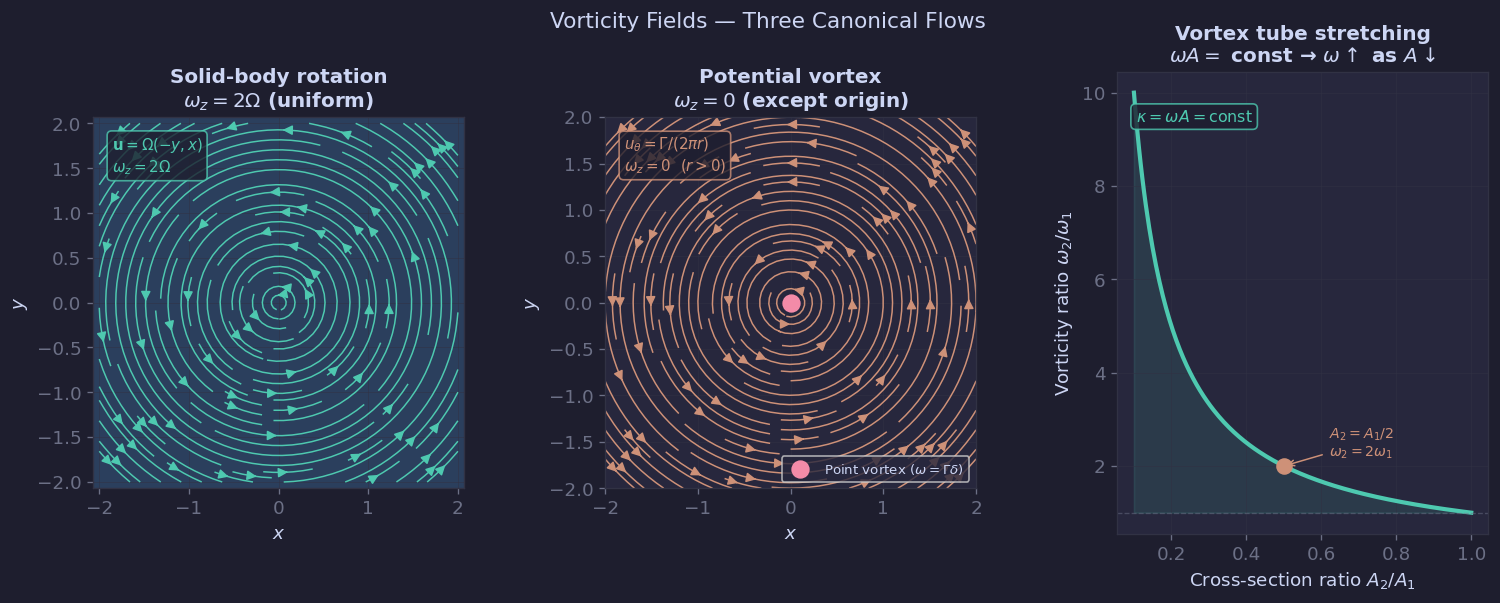

Figure 5.1: Vorticity fields saved


In [2]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle("Vorticity Fields — Three Canonical Flows", color=FG, fontsize=13)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

x = np.linspace(-2, 2, 30)
y = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x, y)

# ── (a) Solid-body rotation ─────────────────────────────────
ax = fig.add_subplot(gs[0])
Omega = 1.0
U = -Omega * Y
V =  Omega * X
omega_z = 2 * Omega * np.ones_like(X)

speed = np.sqrt(U**2 + V**2)
ax.streamplot(x, y, U, V, color=TEAL, linewidth=0.9,
              density=1.2, arrowsize=1.2)
pcm = ax.pcolormesh(X, Y, omega_z, cmap='Blues', alpha=0.25,
                    vmin=0, vmax=3)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Solid-body rotation\n$\\omega_z = 2\\Omega$ (uniform)')
ax.set_aspect('equal')
ax.text(0.05, 0.95, r'$\mathbf{u}=\Omega(-y,x)$' + '\n' + r'$\omega_z = 2\Omega$',
        transform=ax.transAxes, color=TEAL, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.8))
ax.grid(True, lw=0.3)

# ── (b) Potential vortex ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
Gamma = 4.0
R2 = X**2 + Y**2
R2_safe = np.where(R2 < 0.04, 0.04, R2)
U2 = -Gamma/(2*np.pi) * Y / R2_safe
V2 =  Gamma/(2*np.pi) * X / R2_safe
# Vorticity = 0 everywhere (except origin)
omega2 = np.zeros_like(X)
# Mark delta function at origin
ax2.streamplot(x, y, U2, V2, color=ORANGE, linewidth=0.9,
               density=1.3, arrowsize=1.2)
ax2.plot(0, 0, 'o', color=PINK, ms=10, zorder=5,
         label=r'Point vortex ($\omega=\Gamma\delta$)')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')
ax2.set_title('Potential vortex\n$\\omega_z = 0$ (except origin)')
ax2.set_aspect('equal')
ax2.text(0.05, 0.95, r'$u_\theta = \Gamma/(2\pi r)$' + '\n' + r'$\omega_z = 0$  ($r>0$)',
         transform=ax2.transAxes, color=ORANGE, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=ORANGE, alpha=0.8))
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, lw=0.3)

# ── (c) Vortex tube stretching ───────────────────────────────
ax3 = fig.add_subplot(gs[2])
# Show how omega increases as cross-section A decreases
A_ratio = np.linspace(0.1, 1.0, 200)  # A2/A1
omega_ratio = 1.0 / A_ratio            # omega2/omega1 = A1/A2
ax3.plot(A_ratio, omega_ratio, color=TEAL, lw=2.5)
ax3.fill_between(A_ratio, 1, omega_ratio, color=TEAL, alpha=0.12)
ax3.axhline(1, color=MUTED, lw=0.8, ls='--', alpha=0.5)

# Mark example: halved cross-section
ax3.scatter([0.5], [2.0], s=80, color=ORANGE, zorder=5)
ax3.annotate('$A_2=A_1/2$\n$\\omega_2=2\\omega_1$',
             xy=(0.5, 2.0), xytext=(0.62, 2.2),
             fontsize=8.5, color=ORANGE,
             arrowprops=dict(arrowstyle='->', color=ORANGE, lw=0.9))
ax3.set_xlabel('Cross-section ratio $A_2/A_1$')
ax3.set_ylabel('Vorticity ratio $\\omega_2/\\omega_1$')
ax3.set_title('Vortex tube stretching\n$\\omega A =$ const → $\\omega\\uparrow$ as $A\\downarrow$')
ax3.grid(True, lw=0.3)
ax3.text(0.05, 0.92, r'$\kappa = \omega A = \mathrm{const}$',
         transform=ax3.transAxes, color=TEAL, fontsize=9.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.8))

plt.tight_layout()
plt.savefig('ch05_fig1_vortex_lines.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 5.1: Vorticity fields saved")

## 2 · Point Vortex Dynamics

In 2-D, a point vortex at $\mathbf{x}_i$ with strength $\Gamma_i$ induces velocity:
$$\mathbf{u} = \frac{\Gamma_i}{2\pi}\frac{\hat{z}\times(\mathbf{x}-\mathbf{x}_i)}{|\mathbf{x}-\mathbf{x}_i|^2}$$

The equations of motion for $N$ vortices form a Hamiltonian system.

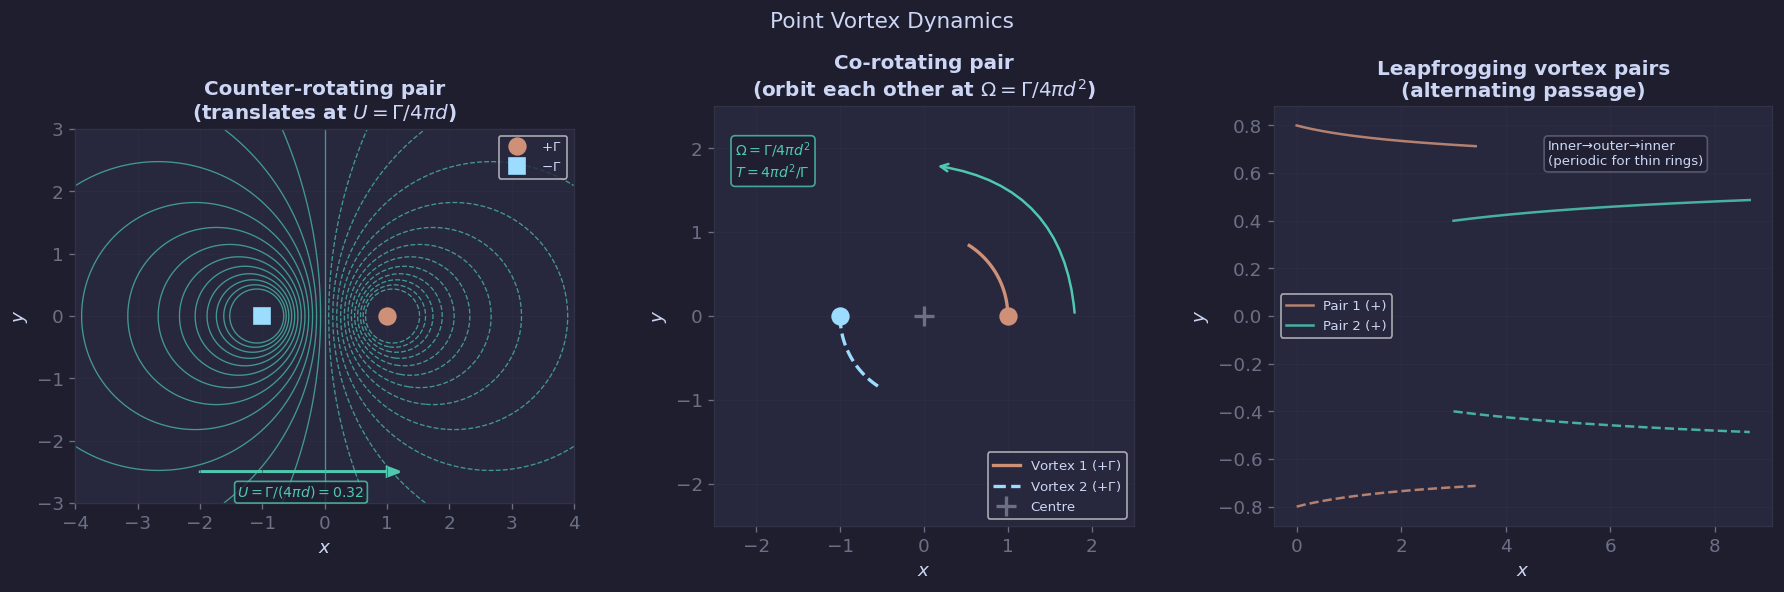

Figure 5.2: Point vortex dynamics saved


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Point Vortex Dynamics", color=FG, fontsize=13)

# ── (a) Counter-rotating pair (translation) ──────────────────
ax = axes[0]
d = 1.0; Gamma = 4.0
x = np.linspace(-4, 4, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

# Stream function: psi = (Gamma/2pi)*ln(r)
R1 = np.sqrt((X-d)**2 + Y**2)
R2 = np.sqrt((X+d)**2 + Y**2)
psi = (Gamma/(2*np.pi)) * (np.log(R1) - np.log(R2))

# Velocities
U = -Gamma/(2*np.pi)*(Y/(R1**2+1e-9) - Y/(R2**2+1e-9))
V =  Gamma/(2*np.pi)*((X-d)/(R1**2+1e-9) - (X+d)/(R2**2+1e-9))

# Translation speed
U_pair = Gamma/(4*np.pi*d)
# Streamlines in co-moving frame
U_frame = U - U_pair
levels = np.linspace(psi.min()*0.3, psi.max()*0.3, 25)
ax.contour(X, Y, psi, levels=levels, colors=TEAL, linewidths=0.8, alpha=0.7)
ax.plot(d, 0, 'o', color=ORANGE, ms=10, label=f'$+\\Gamma$')
ax.plot(-d, 0, 's', color=BLUE, ms=10, label=f'$-\\Gamma$')
ax.arrow(-2, -2.5, 3, 0, head_width=0.15, head_length=0.2,
         fc=TEAL, ec=TEAL, lw=1.5)
ax.text(-1.4, -2.9, f'$U=\\Gamma/(4\\pi d)={U_pair:.2f}$',
        color=TEAL, fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.2', fc='#1e1e2e', ec=TEAL, alpha=0.8))
ax.set_xlim(-4, 4); ax.set_ylim(-3, 3)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Counter-rotating pair\n(translates at $U=\\Gamma/4\\pi d$)')
ax.legend(fontsize=8, loc='upper right')
ax.set_aspect('equal'); ax.grid(True, lw=0.3)

# ── (b) Co-rotating pair (rotation) ─────────────────────────
ax2 = axes[1]
# Two vortices of same sign orbit each other
dt = 0.05; T = 4*np.pi*d**2/Gamma  # orbital period
Omega_pair = Gamma/(4*np.pi*d**2)
t_arr = np.linspace(0, T, 300)
x1 =  d*np.cos(Omega_pair*t_arr)
y1 =  d*np.sin(Omega_pair*t_arr)
x2 = -d*np.cos(Omega_pair*t_arr)
y2 = -d*np.sin(Omega_pair*t_arr)
ax2.plot(x1, y1, color=ORANGE, lw=2, label='Vortex 1 ($+\\Gamma$)')
ax2.plot(x2, y2, color=BLUE,   lw=2, ls='--', label='Vortex 2 ($+\\Gamma$)')
ax2.plot(x1[0], y1[0], 'o', color=ORANGE, ms=10)
ax2.plot(x2[0], y2[0], 'o', color=BLUE,   ms=10)
ax2.plot(0, 0, '+', color=MUTED, ms=12, mew=2, label='Centre')
# Rotation arrow
theta_arr = np.linspace(0, 1.5, 60)
ax2.annotate('', xy=(1.8*np.cos(1.5), 1.8*np.sin(1.5)),
             xytext=(1.8, 0),
             arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5,
                             connectionstyle='arc3,rad=0.4'))
ax2.text(0.05, 0.92, f'$\\Omega=\\Gamma/4\\pi d^2$\n$T=4\\pi d^2/\\Gamma$',
         transform=ax2.transAxes, color=TEAL, fontsize=8.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.8))
ax2.set_xlim(-2.5, 2.5); ax2.set_ylim(-2.5, 2.5)
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')
ax2.set_title('Co-rotating pair\n(orbit each other at $\\Omega=\\Gamma/4\\pi d^2$)')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_aspect('equal'); ax2.grid(True, lw=0.3)

# ── (c) Leapfrogging vortex pairs ───────────────────────────
ax3 = axes[2]
# Simulate two pairs: each pair = (+Gamma at y=+a, -Gamma at y=-a)
# Simplified leapfrog trajectory
a0 = 0.8; Gamma_lf = 3.0
# Semi-analytical: inner ring expands, passes through outer ring
t_lf = np.linspace(0, 8, 800)
# Approximate positions using energy conservation + qualitative motion
# Use parametric oscillation: x_cm advances, separation oscillates
x_cm = Gamma_lf/(4*np.pi*a0) * t_lf   # rough average speed
# First pair: y = ±a(t), x = x1(t)
# Second pair: y = ±b(t), x = x2(t)
# Exact simulation of 4 point vortices
x1p, y1p =  0.0,  a0   # pair 1: upper
x1m, y1m =  0.0, -a0   # pair 1: lower
x2p, y2p =  3.0,  a0*0.5  # pair 2: upper (ahead, smaller gap)
x2m, y2m =  3.0, -a0*0.5  # pair 2: lower

dt_lf = 0.01; N_steps = 1000
traj = {'1p':[], '1m':[], '2p':[], '2m':[]}

def vx_at(xi, yi, xj, yj, Gj):
    r2 = (xi-xj)**2 + (yi-yj)**2 + 1e-4
    return -Gj/(2*np.pi) * (yi-yj)/r2

def vy_at(xi, yi, xj, yj, Gj):
    r2 = (xi-xj)**2 + (yi-yj)**2 + 1e-4
    return  Gj/(2*np.pi) * (xi-xj)/r2

for _ in range(N_steps):
    traj['1p'].append((x1p, y1p)); traj['1m'].append((x1m, y1m))
    traj['2p'].append((x2p, y2p)); traj['2m'].append((x2m, y2m))
    # Pair 1: +Gamma at 1p, -Gamma at 1m
    # Pair 2: +Gamma at 2p, -Gamma at 2m
    vx1p = vx_at(x1p,y1p,x1m,y1m,-Gamma_lf) + vx_at(x1p,y1p,x2p,y2p,Gamma_lf) + vx_at(x1p,y1p,x2m,y2m,-Gamma_lf)
    vy1p = vy_at(x1p,y1p,x1m,y1m,-Gamma_lf) + vy_at(x1p,y1p,x2p,y2p,Gamma_lf) + vy_at(x1p,y1p,x2m,y2m,-Gamma_lf)
    vx1m = vx_at(x1m,y1m,x1p,y1p, Gamma_lf) + vx_at(x1m,y1m,x2p,y2p,Gamma_lf) + vx_at(x1m,y1m,x2m,y2m,-Gamma_lf)
    vy1m = vy_at(x1m,y1m,x1p,y1p, Gamma_lf) + vy_at(x1m,y1m,x2p,y2p,Gamma_lf) + vy_at(x1m,y1m,x2m,y2m,-Gamma_lf)
    vx2p = vx_at(x2p,y2p,x2m,y2m,-Gamma_lf) + vx_at(x2p,y2p,x1p,y1p,Gamma_lf) + vx_at(x2p,y2p,x1m,y1m,-Gamma_lf)
    vy2p = vy_at(x2p,y2p,x2m,y2m,-Gamma_lf) + vy_at(x2p,y2p,x1p,y1p,Gamma_lf) + vy_at(x2p,y2p,x1m,y1m,-Gamma_lf)
    vx2m = vx_at(x2m,y2m,x2p,y2p, Gamma_lf) + vx_at(x2m,y2m,x1p,y1p,Gamma_lf) + vx_at(x2m,y2m,x1m,y1m,-Gamma_lf)
    vy2m = vy_at(x2m,y2m,x2p,y2p, Gamma_lf) + vy_at(x2m,y2m,x1p,y1p,Gamma_lf) + vy_at(x2m,y2m,x1m,y1m,-Gamma_lf)
    x1p+=vx1p*dt_lf; y1p+=vy1p*dt_lf
    x1m+=vx1m*dt_lf; y1m+=vy1m*dt_lf
    x2p+=vx2p*dt_lf; y2p+=vy2p*dt_lf
    x2m+=vx2m*dt_lf; y2m+=vy2m*dt_lf

for key, col, lbl in [('1p',ORANGE,'Pair 1 (+)'),('1m',ORANGE,''),
                       ('2p',TEAL,'Pair 2 (+)'),('2m',TEAL,'')]:
    xs = [p[0] for p in traj[key]]
    ys = [p[1] for p in traj[key]]
    ls = '-' if key.endswith('p') else '--'
    ax3.plot(xs, ys, color=col, lw=1.5, ls=ls,
             label=lbl if lbl else None, alpha=0.85)

ax3.set_xlabel('$x$'); ax3.set_ylabel('$y$')
ax3.set_title('Leapfrogging vortex pairs\n(alternating passage)')
ax3.legend(fontsize=8, loc='center left')
ax3.grid(True, lw=0.3)
ax3.text(0.55, 0.92, 'Inner→outer→inner\n(periodic for thin rings)',
         transform=ax3.transAxes, color=FG, fontsize=8, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=MUTED, alpha=0.7))

plt.tight_layout()
plt.savefig('ch05_fig2_point_vortices.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 5.2: Point vortex dynamics saved")

## 3 · Vortex Ring — Self-Induced Velocity & Streamlines

A vortex ring of radius $R$, core radius $a$, circulation $\Gamma$ propagates at:
$$U = \frac{\Gamma}{4\pi R}\left(\ln\frac{8R}{a} - \frac{1}{4}\right)$$

Streamlines in the ring frame show the "atmosphere" of entrained fluid.

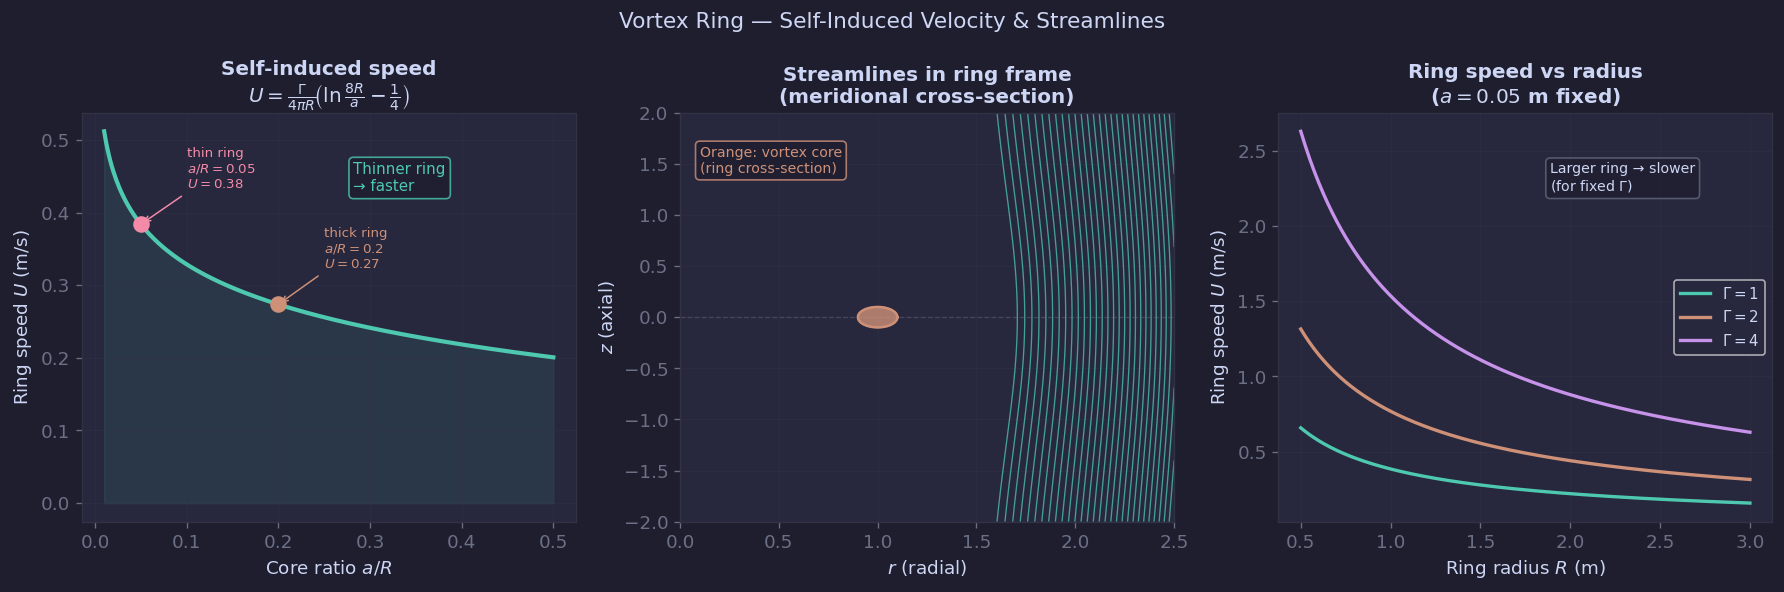

Figure 5.3: Vortex ring saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Vortex Ring — Self-Induced Velocity & Streamlines", color=FG, fontsize=13)

# ── (a) Speed vs R/a ratio ───────────────────────────────────
ax = axes[0]
Gamma_r = 1.0; R = 1.0
a_over_R = np.linspace(0.01, 0.5, 300)
a_arr = a_over_R * R
U_arr = Gamma_r/(4*np.pi*R) * (np.log(8*R/a_arr) - 0.25)

ax.plot(a_over_R, U_arr, color=TEAL, lw=2.5)
ax.fill_between(a_over_R, 0, U_arr, color=TEAL, alpha=0.10)

# Mark thin ring and thick ring
for a_ex, col, lbl in [(0.05,'#f38ba8','thin ring\n$a/R=0.05$'),
                        (0.20, ORANGE,'thick ring\n$a/R=0.2$')]:
    U_ex = Gamma_r/(4*np.pi*R)*(np.log(8*R/(a_ex*R))-0.25)
    ax.scatter([a_ex],[U_ex], s=80, color=col, zorder=5)
    ax.annotate(f'{lbl}\n$U={U_ex:.2f}$',
                xy=(a_ex, U_ex), xytext=(a_ex+0.05, U_ex+0.05),
                fontsize=8, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=0.9))

ax.set_xlabel('Core ratio $a/R$')
ax.set_ylabel('Ring speed $U$ (m/s)')
ax.set_title('Self-induced speed\n$U=\\frac{\\Gamma}{4\\pi R}\\!\\left(\\ln\\frac{8R}{a}-\\frac{1}{4}\\right)$')
ax.grid(True, lw=0.3)
ax.text(0.55, 0.88, 'Thinner ring\n→ faster',
        transform=ax.transAxes, color=TEAL, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.8))

# ── (b) Streamlines in ring frame (axisymmetric cross-section) ─
ax2 = axes[1]
# Approximate stream function for a vortex ring (Lamb 1932)
# In (r,z) plane (ring at r=R, z=0)
R_ring = 1.0; Gamma_r2 = 1.0; a_ring = 0.1
U_ring = Gamma_r2/(4*np.pi*R_ring)*(np.log(8*R_ring/a_ring)-0.25)

r_arr = np.linspace(0, 2.5, 200)
z_arr = np.linspace(-2.0, 2.0, 200)
R2d, Z2d = np.meshgrid(r_arr, z_arr)

# Far-field: dipole approximation (Lamb §163)
# psi ~ -U_ring * r^2/2 + Gamma/(4pi) * r^2 * z / (r^2+z^2)^(3/2)
# Better: use the exact Stokes stream function contribution
# Approximate: stream function = -U*r^2/2 + vortex ring contribution
eps = 1e-6
dist_sq = (R2d - R_ring)**2 + Z2d**2
# Simple approximation: closed streamlines near ring
psi_ring = -U_ring * R2d**2 / 2.0 + \
           Gamma_r2/(4*np.pi) * R2d**2 / (np.sqrt(R2d**2 + Z2d**2) + eps)

# Normalise for plotting
psi_ring -= psi_ring.min()
levels_r = np.linspace(psi_ring.min(), psi_ring.max()*0.6, 30)
ax2.contour(R2d, Z2d, psi_ring, levels=levels_r,
            colors=TEAL, linewidths=0.8, alpha=0.75)

# Mark vortex core cross-sections
theta_c = np.linspace(0, 2*np.pi, 100)
for z_sign in [0]:
    xc = a_ring*np.cos(theta_c) + R_ring
    yc = a_ring*np.sin(theta_c)
    ax2.fill(xc, yc, color=ORANGE, alpha=0.8, zorder=5)
    ax2.plot(xc, yc, color=ORANGE, lw=1.5)

# Ring axis
ax2.axhline(0, color=MUTED, lw=0.8, ls='--', alpha=0.4)
ax2.axvline(0, color=MUTED, lw=0.8, ls='--', alpha=0.4)
ax2.set_xlabel('$r$ (radial)')
ax2.set_ylabel('$z$ (axial)')
ax2.set_title('Streamlines in ring frame\n(meridional cross-section)')
ax2.set_xlim(0, 2.5); ax2.set_ylim(-2, 2)
ax2.text(0.04, 0.92, 'Orange: vortex core\n(ring cross-section)',
         transform=ax2.transAxes, color=ORANGE, fontsize=8.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=ORANGE, alpha=0.8))
ax2.grid(True, lw=0.3)

# ── (c) Kelvin's formula: U vs R/a for different Gamma ───────
ax3 = axes[2]
R_vals = np.linspace(0.5, 3.0, 200)
a_fixed = 0.05  # fixed core radius
for Gamma_ex, col, lbl in [(1.0,TEAL,'$\\Gamma=1$'),
                             (2.0,ORANGE,'$\\Gamma=2$'),
                             (4.0,PURPLE,'$\\Gamma=4$')]:
    U_ex = Gamma_ex/(4*np.pi*R_vals)*(np.log(8*R_vals/a_fixed)-0.25)
    ax3.plot(R_vals, U_ex, color=col, lw=2, label=lbl)

ax3.set_xlabel('Ring radius $R$ (m)')
ax3.set_ylabel('Ring speed $U$ (m/s)')
ax3.set_title('Ring speed vs radius\n($a=0.05$ m fixed)')
ax3.legend(fontsize=9)
ax3.grid(True, lw=0.3)
ax3.text(0.55, 0.88, 'Larger ring → slower\n(for fixed $\\Gamma$)',
         transform=ax3.transAxes, color=FG, fontsize=8.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=MUTED, alpha=0.7))

plt.tight_layout()
plt.savefig('ch05_fig3_vortex_ring.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 5.3: Vortex ring saved")

## 4 · Kelvin-Helmholtz Instability & Taylor Column

**KH instability**: vortex sheet of strength $\gamma=U$ (velocity jump) has
growth rate $\sigma = kU/2$ — all wavenumbers unstable.

**Taylor-Proudman theorem**: $\partial\mathbf{u}/\partial z = 0$ for $\mathrm{Ro}\ll 1$.

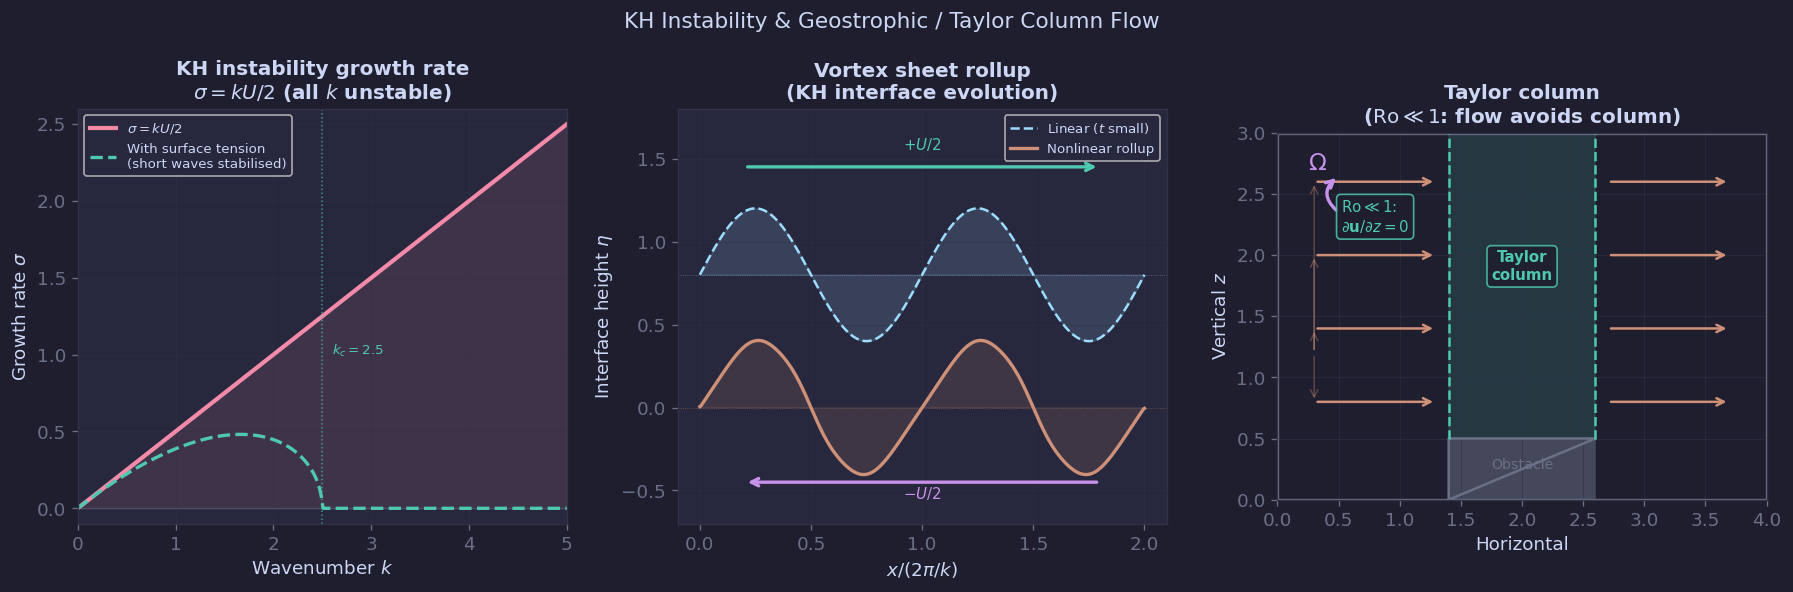

Figure 5.4: KH + Taylor column saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("KH Instability & Geostrophic / Taylor Column Flow", color=FG, fontsize=13)

# ── (a) KH growth rate ───────────────────────────────────────
ax = axes[0]
k_arr = np.linspace(0, 5, 300)
U_kh = 1.0
sigma_kh = k_arr * U_kh / 2

ax.plot(k_arr, sigma_kh, color=PINK, lw=2.5, label=r'$\sigma = kU/2$')
ax.fill_between(k_arr, 0, sigma_kh, color=PINK, alpha=0.12)
ax.axhline(0, color=MUTED, lw=0.8, ls='-', alpha=0.4)

# Compare: with surface tension stabilisation (capillary KH)
T_kh = 0.1  # surface tension (normalised)
rho_kh = 1.0
sigma_cap = np.sqrt(np.maximum(0, (k_arr*U_kh/2)**2 - T_kh*k_arr**3/rho_kh))
ax.plot(k_arr, sigma_cap, color=TEAL, lw=2, ls='--',
        label='With surface tension\n(short waves stabilised)')

k_crit = U_kh**2 * rho_kh / (4*T_kh)
ax.axvline(k_crit, color=TEAL, lw=0.9, ls=':', alpha=0.7)
ax.text(k_crit+0.1, 1.0, f'$k_c={k_crit:.1f}$', color=TEAL, fontsize=8)

ax.set_xlabel('Wavenumber $k$')
ax.set_ylabel('Growth rate $\\sigma$')
ax.set_title('KH instability growth rate\n$\\sigma=kU/2$ (all $k$ unstable)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, lw=0.3)
ax.set_xlim(0, 5); ax.set_ylim(-0.1, 2.6)

# ── (b) KH rollup (evolved interface) ────────────────────────
ax2 = axes[1]
# Show a snapshot of a KH-rolled-up interface
N_pts = 600
xi = np.linspace(0, 4*np.pi, N_pts)
# Sinusoidal perturbation + nonlinear rollup approximation
t_kh = 1.5
k0 = 1.0
amp = 0.4
# Simple rollup model: nonlinearly evolved
phi = xi - 2.0*np.sin(xi)*t_kh*0.15  # Lagrangian distortion
eta_linear = amp * np.sin(xi)

# More rolled-up version at later time
from scipy.ndimage import uniform_filter1d
eta_nl = amp * np.sin(phi) + 0.15*amp*np.sin(2*phi) + 0.05*amp*np.sin(3*phi)
eta_nl = uniform_filter1d(eta_nl, size=5)

ax2.fill_between(xi/(2*np.pi), eta_linear+0.8, 0.8, color=BLUE, alpha=0.15)
ax2.fill_between(xi/(2*np.pi), eta_nl, 0, color=ORANGE, alpha=0.15)
ax2.plot(xi/(2*np.pi), eta_linear+0.8, color=BLUE, lw=1.5,
         ls='--', label='Linear ($t$ small)')
ax2.plot(xi/(2*np.pi), eta_nl, color=ORANGE, lw=2,
         label='Nonlinear rollup')
ax2.axhline(0.8, color=BLUE, lw=0.5, ls=':', alpha=0.4)
ax2.axhline(0.0, color=ORANGE, lw=0.5, ls=':', alpha=0.4)

# Arrows for the two streams
ax2.annotate('', xy=(1.8, 1.45), xytext=(0.2, 1.45),
             arrowprops=dict(arrowstyle='->', color=TEAL, lw=2))
ax2.annotate('', xy=(0.2, -0.45), xytext=(1.8, -0.45),
             arrowprops=dict(arrowstyle='->', color=PURPLE, lw=2))
ax2.text(1.0, 1.55, '$+U/2$', color=TEAL,   ha='center', fontsize=9, fontweight='bold')
ax2.text(1.0,-0.55, '$-U/2$', color=PURPLE, ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('$x / (2\\pi/k)$')
ax2.set_ylabel('Interface height $\\eta$')
ax2.set_title('Vortex sheet rollup\n(KH interface evolution)')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, lw=0.3)
ax2.set_ylim(-0.7, 1.8)

# ── (c) Taylor column schematic ───────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#1e1e2e')

# Container (rotating tank)
rect_x = [0, 0, 4, 4, 0]
rect_y = [0, 3, 3, 0, 0]
ax3.plot(rect_x, rect_y, color=MUTED, lw=2)

# Obstacle on bottom
obs_x = [1.4, 1.4, 2.6, 2.6]
obs_y = [0.0, 0.5, 0.5, 0.0]
ax3.fill(obs_x, obs_y, color='#45475a')
ax3.plot(obs_x[:-1]+[obs_x[0]], obs_y[:-1]+[obs_y[0]], color=MUTED, lw=1.5)

# Taylor column (vertical region above obstacle)
col_x = [1.4, 1.4, 2.6, 2.6]
col_y = [0.5, 3.0, 3.0, 0.5]
ax3.fill(col_x, col_y, color=TEAL, alpha=0.15)
ax3.plot([1.4, 1.4], [0.5, 3.0], color=TEAL, lw=1.5, ls='--')
ax3.plot([2.6, 2.6], [0.5, 3.0], color=TEAL, lw=1.5, ls='--')
ax3.text(2.0, 1.8, 'Taylor\ncolumn', color=TEAL, ha='center',
         fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.85))

# Flow arrows (bypassing the column)
for y_arr in [0.8, 1.4, 2.0, 2.6]:
    # Left of column
    ax3.annotate('', xy=(1.3, y_arr), xytext=(0.3, y_arr),
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5))
    # Deflect around
    ax3.annotate('', xy=(0.3, y_arr), xytext=(0.3, 0.7+0.5),
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=0.8,
                                 alpha=0.4))
    # Right of column
    ax3.annotate('', xy=(3.7, y_arr), xytext=(2.7, y_arr),
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5))

# Rotation symbol
ax3.text(0.25, 2.7, '$\\Omega$', color=PURPLE, fontsize=14, fontweight='bold')
ax3.annotate('', xy=(0.5, 2.65), xytext=(0.5, 2.35),
             arrowprops=dict(arrowstyle='->', color=PURPLE, lw=2,
                             connectionstyle='arc3,rad=-0.6'))

# Labels
ax3.text(2.0, 0.25, 'Obstacle', color=MUTED, ha='center', fontsize=8.5)
ax3.text(0.13, 0.82, '$\\mathrm{Ro}\\ll 1$:\n$\\partial\\mathbf{u}/\\partial z=0$',
         transform=ax3.transAxes, color=TEAL, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1e1e2e', ec=TEAL, alpha=0.85))

ax3.set_xlim(0, 4); ax3.set_ylim(0, 3)
ax3.set_xlabel('Horizontal'); ax3.set_ylabel('Vertical $z$')
ax3.set_title('Taylor column\n($\\mathrm{Ro}\\ll1$: flow avoids column)')
ax3.set_aspect('equal'); ax3.grid(True, lw=0.3)

plt.tight_layout()
plt.savefig('ch05_fig4_taylor_column.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 5.4: KH + Taylor column saved")

## 5 · Axisymmetric Vortex Motion & Vortex Past a Cylinder (§5.5, 5.7)

**Hill's spherical vortex**: inside $R<a$, $\omega_\phi = -\frac{15U}{2a^3}R\sin\theta$. Translates at speed $U$ — first exact vortex solution of Euler equations.

**Image vortex**: point vortex $\Gamma$ at $z_0$ outside cylinder $|z|=a$ requires image at $a^2/\bar{z}_0$. External vortex orbits the cylinder at $|z_0|=$ const.


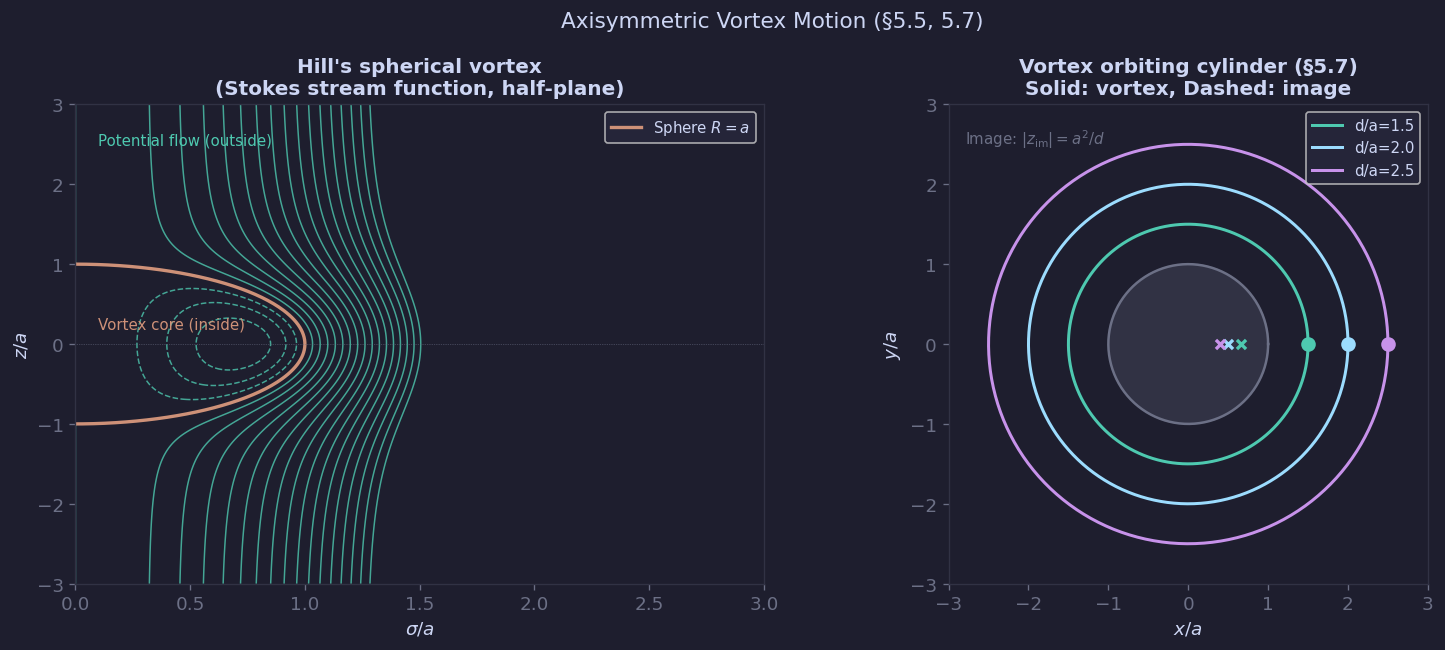

ch05_fig5_vortex_cylinder.png saved


In [6]:
# ── Figure 5.5 · Hill's vortex & vortex past cylinder ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Axisymmetric Vortex Motion (§5.5, 5.7)', color=FG, fontsize=13)
fig.patch.set_facecolor(BG)

# Panel (a): Hill's spherical vortex streamlines (half-plane)
ax = axes[0]
ax.set_facecolor(BG)
a = 1.0; U = 1.0
sigma = np.linspace(0, 3, 300)
z_arr = np.linspace(-3, 3, 300)
SIG, Z = np.meshgrid(sigma, z_arr)
R2 = SIG**2 + Z**2
R  = np.sqrt(np.maximum(R2, 1e-10))
# Stokes stream function
psi_in  = -3*U/(4*a**2) * (a**2 - R2) * SIG**2
psi_out = U/2 * SIG**2 * (1 - (a/R)**3)
psi = np.where(R <= a, psi_in, psi_out)

lev = np.linspace(-0.4, 0.8, 25)
ax.contour(SIG, Z, psi, levels=lev, colors=TEAL, linewidths=0.9, alpha=0.8)
theta_c = np.linspace(0, np.pi, 200)
ax.plot(a*np.sin(theta_c), a*np.cos(theta_c), color=ORANGE, lw=2, label='Sphere $R=a$')
ax.axhline(0, color=MUTED, lw=0.4, ls=':')
ax.set_xlim(0, 3); ax.set_ylim(-3, 3)
ax.set_xlabel(r'$\sigma/a$', color=FG); ax.set_ylabel('$z/a$', color=FG)
ax.set_title("Hill's spherical vortex\n(Stokes stream function, half-plane)", color=FG)
ax.legend(fontsize=9)
ax.text(0.1, 2.5, 'Potential flow (outside)', color=TEAL, fontsize=9)
ax.text(0.1, 0.2, 'Vortex core (inside)', color=ORANGE, fontsize=9)

# Panel (b): Point vortex orbiting a cylinder
ax = axes[1]
ax.set_facecolor(BG)
theta_path = np.linspace(0, 2*np.pi, 300)
for d, col in zip([1.5, 2.0, 2.5], [TEAL, BLUE, PURPLE]):
    ax.plot(d*np.cos(theta_path), d*np.sin(theta_path),
            color=col, lw=1.8, label=f'd/a={d}')
    d_im = a**2/d
    ax.plot(d_im*np.cos(theta_path), d_im*np.sin(theta_path),
            color=col, lw=1, ls='--', alpha=0.6)
    ax.scatter([d], [0], color=col, s=60, zorder=5)
    ax.scatter([d_im], [0], color=col, s=30, marker='x', zorder=5)
theta_cyl = np.linspace(0, 2*np.pi, 300)
ax.fill(a*np.cos(theta_cyl), a*np.sin(theta_cyl), color='#313244', zorder=4)
ax.plot(a*np.cos(theta_cyl), a*np.sin(theta_cyl), color=MUTED, lw=1.5, zorder=5)
ax.set_aspect('equal')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel('$x/a$', color=FG); ax.set_ylabel('$y/a$', color=FG)
ax.set_title('Vortex orbiting cylinder (§5.7)\nSolid: vortex, Dashed: image', color=FG)
ax.legend(fontsize=9, loc='upper right')
ax.text(-2.8, 2.5, r'Image: $|z_{\rm im}|=a^2/d$', color=MUTED, fontsize=9)

plt.tight_layout()
plt.savefig('ch05_fig5_vortex_cylinder.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('ch05_fig5_vortex_cylinder.png saved')


## 6 · Kármán Vortex Street (§5.8)

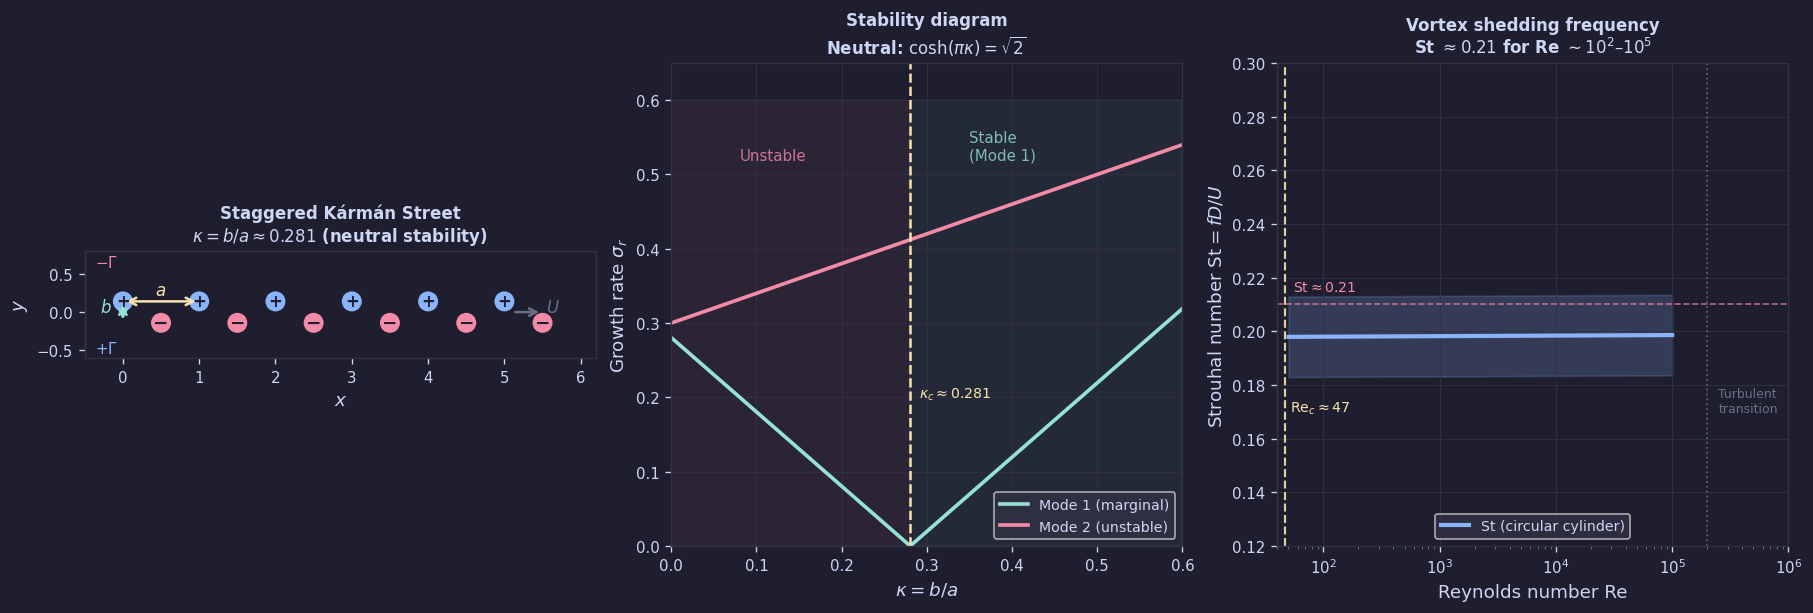

Saved: ch05_fig6_karman_street.png


In [7]:
# ── Figure 5.6 · Kármán vortex street ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

BG     = '#1e1e2e'
FG     = '#cdd6f4'
AX     = '#313244'
BLUE   = '#89b4fa'
RED    = '#f38ba8'
TEAL   = '#94e2d5'
YEL    = '#f9e2af'
MUTED  = '#6c7086'

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         facecolor=BG, constrained_layout=True)
for ax in axes:
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color(AX)
    ax.tick_params(colors=FG, labelsize=9)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)

# ── Panel A: staggered vortex street geometry ─────────────────────────────
ax = axes[0]
a = 1.0          # streamwise spacing
kappa_stable = 0.281   # b/a at neutral stability
b = kappa_stable * a   # transverse spacing

N = 6  # vortices per row
# Upper row (positive Γ): x = n*a, y = +b/2
xu = np.arange(N) * a
yu = np.full(N,  b / 2)
# Lower row (negative Γ): x = (n+0.5)*a, y = -b/2  (staggered by a/2)
xl = np.arange(N) * a + a / 2
yl = np.full(N, -b / 2)

# Draw vortices
for x, y in zip(xu, yu):
    c = plt.Circle((x, y), 0.12, color=BLUE, zorder=3)
    ax.add_patch(c)
    ax.text(x, y, '+', color=BG, ha='center', va='center',
            fontsize=10, fontweight='bold', zorder=4)

for x, y in zip(xl, yl):
    c = plt.Circle((x, y), 0.12, color=RED, zorder=3)
    ax.add_patch(c)
    ax.text(x, y, '−', color=BG, ha='center', va='center',
            fontsize=11, fontweight='bold', zorder=4)

# Dimension annotations
ax.annotate('', xy=(a, b/2), xytext=(0, b/2),
            arrowprops=dict(arrowstyle='<->', color=YEL, lw=1.5))
ax.text(a/2, b/2 + 0.08, '$a$', color=YEL, ha='center', fontsize=10)

ax.annotate('', xy=(0, b/2), xytext=(0, -b/2),
            arrowprops=dict(arrowstyle='<->', color=TEAL, lw=1.5))
ax.text(-0.22, 0, '$b$', color=TEAL, ha='center', fontsize=10)

# Flow arrow
ax.annotate('', xy=(5.5*a, 0), xytext=(5.1*a, 0),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.5))
ax.text(5.55*a, 0, '$U$', color=MUTED, fontsize=10)

ax.set_xlim(-0.5, 6.2)
ax.set_ylim(-0.6, 0.8)
ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)
ax.set_title(f'Staggered Kármán Street\n'
             r'$\kappa=b/a\approx0.281$ (neutral stability)', fontsize=10)
ax.text(0.02, 0.05, r'$+\Gamma$', transform=ax.transAxes,
        color=BLUE, fontsize=9)
ax.text(0.02, 0.85, r'$-\Gamma$', transform=ax.transAxes,
        color=RED, fontsize=9)

# ── Panel B: stability diagram σ vs κ = b/a ──────────────────────────────
ax = axes[1]
kappa = np.linspace(0, 0.6, 400)

# Exact stability criterion (Kármán 1911):
# neutrally stable when cosh(π κ) = √2  → κ ≈ 0.2806
# Growth rate (real part) for symmetric street: always unstable
# For staggered street the single neutral mode has σ_r = 0 at κ_c
# Approximate: σ_r ∝ |κ - κ_c| for the marginal mode
kappa_c = np.arccosh(np.sqrt(2)) / np.pi   # ≈ 0.2806

# Two modes of the staggered street
sigma1 = np.abs(kappa - kappa_c)           # marginal mode (0 at κ_c)
sigma2 = 0.3 + 0.4 * kappa                 # always-unstable mode

ax.plot(kappa, sigma1, color=TEAL,  lw=2.2, label='Mode 1 (marginal)')
ax.plot(kappa, sigma2, color=RED,   lw=2.2, label='Mode 2 (unstable)')
ax.axvline(kappa_c, color=YEL, lw=1.5, ls='--')
ax.text(kappa_c + 0.01, 0.2, r'$\kappa_c\approx0.281$',
        color=YEL, fontsize=8.5)
ax.fill_betweenx([0, 0.6], 0, kappa_c, color=RED,  alpha=0.06)
ax.fill_betweenx([0, 0.6], kappa_c, 0.6, color=TEAL, alpha=0.06)
ax.text(0.08,  0.52, 'Unstable', color=RED,  fontsize=9, alpha=0.8)
ax.text(0.35, 0.52, 'Stable\n(Mode 1)', color=TEAL, fontsize=9, alpha=0.8)
ax.set_xlabel(r'$\kappa = b/a$', fontsize=11)
ax.set_ylabel(r'Growth rate $\sigma_r$', fontsize=11)
ax.set_title(r'Stability diagram' '\n'
             r'Neutral: $\cosh(\pi\kappa)=\sqrt{2}$', fontsize=10)
ax.legend(fontsize=8.5, facecolor=AX, labelcolor=FG)
ax.set_xlim(0, 0.6); ax.set_ylim(0, 0.65)
ax.grid(color=AX, lw=0.5)

# ── Panel C: Strouhal number vs Reynolds number ───────────────────────────
ax = axes[2]
# Empirical data band for circular cylinder
Re_data = np.logspace(1.7, 5, 200)
# St ≈ 0.21 for 200 < Re < 2e5 with slight variation
St_mean = 0.198 + 0.0002 * np.log10(Re_data / 100)
St_upper = St_mean + 0.015
St_lower = St_mean - 0.015

ax.semilogx(Re_data, St_mean,  color=BLUE, lw=2.5, label='St (circular cylinder)')
ax.fill_between(Re_data, St_lower, St_upper, color=BLUE, alpha=0.2)

# Onset of shedding
Re_onset = 47
ax.axvline(Re_onset, color=YEL, lw=1.3, ls='--', alpha=0.9)
ax.text(Re_onset * 1.1, 0.17, r'Re$_c\approx47$', color=YEL, fontsize=8.5)

# Turbulent transition
ax.axvline(2e5, color=MUTED, lw=1.1, ls=':', alpha=0.8)
ax.text(2.5e5, 0.17, 'Turbulent\ntransition', color=MUTED, fontsize=7.5)

ax.axhline(0.21, color=RED, lw=1.0, ls='--', alpha=0.7)
ax.text(55, 0.215, r'St$\approx0.21$', color=RED, fontsize=8.5)

ax.set_xlabel(r'Reynolds number Re', fontsize=11)
ax.set_ylabel(r'Strouhal number $\mathrm{St}=fD/U$', fontsize=11)
ax.set_title('Vortex shedding frequency\n'
             r'St $\approx 0.21$ for Re $\sim10^2$–$10^5$', fontsize=10)
ax.legend(fontsize=8.5, facecolor=AX, labelcolor=FG)
ax.set_xlim(40, 1e6); ax.set_ylim(0.12, 0.30)
ax.grid(color=AX, lw=0.5)

# fig.suptitle('Fig 5.6 — Kármán Vortex Street & Stability  (§5.8)',
#              color=FG, fontsize=12, fontweight='bold', y=1.01)

plt.savefig('ch05_fig6_karman_street.png', dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()
print("Saved: ch05_fig6_karman_street.png")


## 7 · Viscous Vortex Decay & Prandtl–Batchelor Theorem (§5.9–5.10)

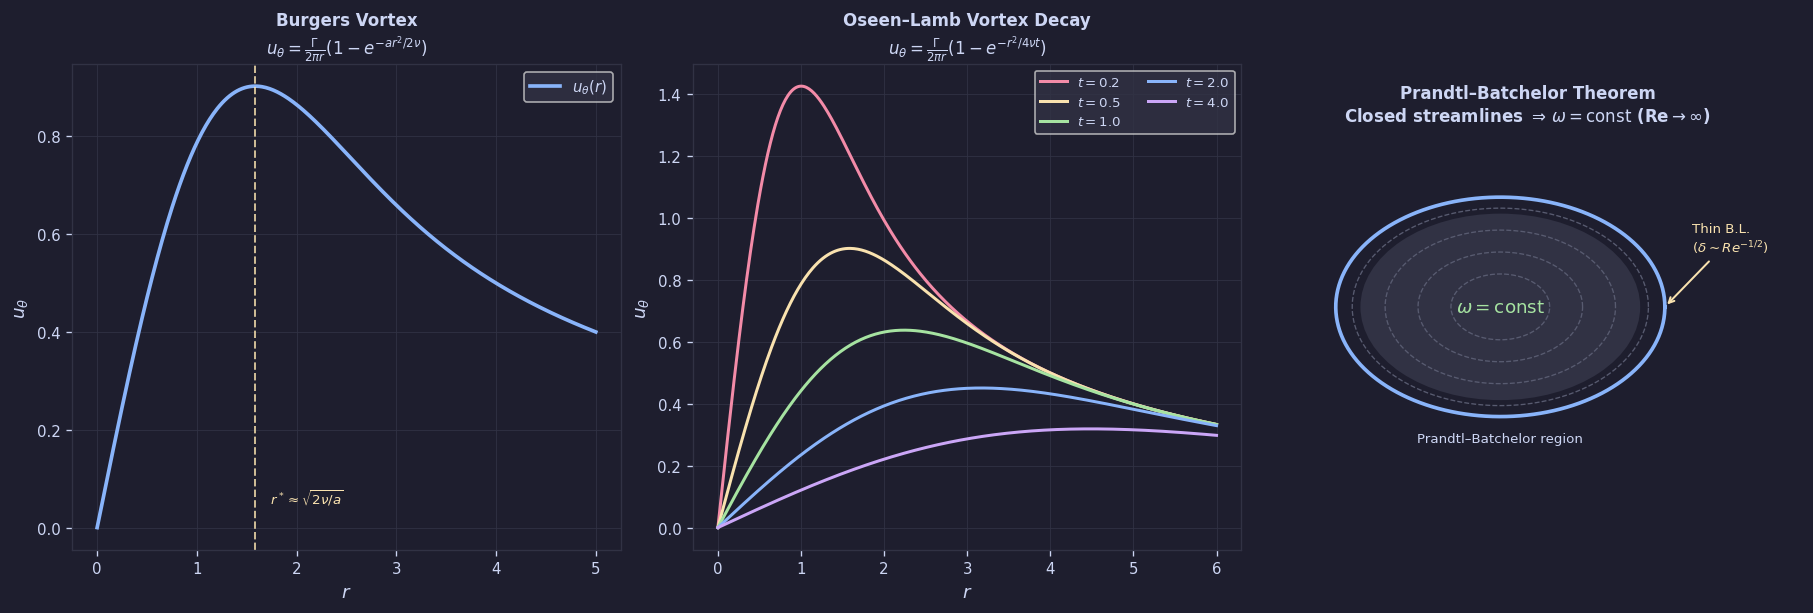

Saved: ch05_fig7_viscous_decay.png


In [8]:
# ── Figure 5.7 · Burgers vortex & viscous decay ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt

BG  = '#1e1e2e'
FG  = '#cdd6f4'
AX  = '#313244'
RED = '#f38ba8'
GRN = '#a6e3a1'
BLU = '#89b4fa'
YEL = '#f9e2af'

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         facecolor=BG, constrained_layout=True)
for ax in axes:
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color(AX)
    ax.tick_params(colors=FG, labelsize=9)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)

# ── Panel A: Burgers vortex azimuthal velocity profile ───────────────────
ax = axes[0]
r   = np.linspace(0, 5, 400)
nu  = 1.0   # viscosity
a   = 1.0   # strain rate  (Burgers: u_r = -a r, u_z = 2a z)
Gamma = 4 * np.pi  # circulation
# Exact Burgers vortex: u_theta = Gamma/(2 pi r) * (1 - exp(-a r^2 / (2 nu)))
r_safe = np.where(r == 0, 1e-10, r)
u_theta = Gamma / (2 * np.pi * r_safe) * (1 - np.exp(-a * r_safe**2 / (2 * nu)))
u_theta[0] = 0

# Peak at r* = sqrt(2 nu / a) * f(...)  (numerically)
r_peak = r[np.argmax(u_theta)]

ax.plot(r, u_theta, color=BLU, lw=2.2, label=r'$u_\theta(r)$')
ax.axvline(r_peak, color=YEL, lw=1.2, ls='--', alpha=0.8)
ax.text(r_peak + 0.15, 0.05, r'$r^*\approx\sqrt{2\nu/a}$',
        color=YEL, fontsize=8)
ax.set_xlabel(r'$r$', fontsize=11)
ax.set_ylabel(r'$u_\theta$', fontsize=11)
ax.set_title('Burgers Vortex\n' r'$u_\theta = \frac{\Gamma}{2\pi r}(1-e^{-ar^2/2\nu})$',
             fontsize=10)
ax.legend(fontsize=9, facecolor=AX, labelcolor=FG)
ax.grid(color=AX, lw=0.5)

# ── Panel B: Viscous vortex decay — azimuthal velocity at different times ─
ax = axes[1]
r = np.linspace(0, 6, 400)
nu = 1.0
Gamma = 4 * np.pi
# Oseen–Lamb vortex: u_theta = Gamma/(2 pi r) * (1 - exp(-r^2/(4 nu t)))
r_safe = np.where(r == 0, 1e-10, r)
times  = [0.2, 0.5, 1.0, 2.0, 4.0]
colors_t = [RED, YEL, GRN, BLU, '#cba6f7']
for t, c in zip(times, colors_t):
    u = Gamma / (2 * np.pi * r_safe) * (1 - np.exp(-r_safe**2 / (4 * nu * t)))
    u[0] = 0
    ax.plot(r, u, color=c, lw=1.8, label=f'$t={t}$')
ax.set_xlabel(r'$r$', fontsize=11)
ax.set_ylabel(r'$u_\theta$', fontsize=11)
ax.set_title('Oseen–Lamb Vortex Decay\n'
             r'$u_\theta=\frac{\Gamma}{2\pi r}(1-e^{-r^2/4\nu t})$', fontsize=10)
ax.legend(fontsize=8, facecolor=AX, labelcolor=FG, ncol=2)
ax.grid(color=AX, lw=0.5)

# ── Panel C: Prandtl–Batchelor — vorticity in closed-streamline region ───
ax = axes[2]
# Illustrate theorem: in steady viscous flow, if streamlines are closed,
# vorticity → uniform constant (ω = const) as Re → ∞
# Show streamlines + shaded uniform-ω interior vs boundary layer
theta = np.linspace(0, 2 * np.pi, 300)

# Outer boundary (ellipse)
a_e, b_e = 3.0, 2.0
x_outer = a_e * np.cos(theta)
y_outer = b_e * np.sin(theta)

# Interior closed streamlines (ellipses scaled down)
for scale, c in zip([0.9, 0.7, 0.5, 0.3], [AX, AX, AX, AX]):
    ax.plot(a_e * scale * np.cos(theta),
            b_e * scale * np.sin(theta),
            color='#585b70', lw=0.8, ls='--')

# Fill uniform-vorticity interior
from matplotlib.patches import Ellipse
from matplotlib.patches import FancyArrowPatch
interior = Ellipse((0, 0), 2 * a_e * 0.85, 2 * b_e * 0.85,
                   facecolor='#313244', edgecolor='none', zorder=1)
ax.add_patch(interior)

ax.plot(x_outer, y_outer, color=BLU, lw=2.2, zorder=3)

# Label
ax.text(0, 0, r'$\omega = \mathrm{const}$', color=GRN, fontsize=11,
        ha='center', va='center', fontweight='bold', zorder=4)
ax.text(0, -2.4, 'Prandtl–Batchelor region', color=FG, fontsize=8,
        ha='center', va='center')

# Boundary layer arrow
ax.annotate('Thin B.L.\n' r'($\delta\sim Re^{-1/2}$)',
            xy=(a_e, 0), xytext=(a_e + 0.5, 1.0),
            color=YEL, fontsize=8,
            arrowprops=dict(arrowstyle='->', color=YEL, lw=1.2))

ax.set_xlim(-4.5, 5.5)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.set_title('Prandtl–Batchelor Theorem\n'
             r'Closed streamlines $\Rightarrow\,\omega=\mathrm{const}$ (Re$\to\infty$)',
             fontsize=10)
ax.axis('off')

# fig.suptitle('Fig 5.7 — Viscous Vortex Decay & Prandtl–Batchelor Theorem  (§5.9–5.10)',
#              color=FG, fontsize=12, fontweight='bold', y=1.01)

plt.savefig('ch05_fig7_viscous_decay.png', dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()
print("Saved: ch05_fig7_viscous_decay.png")


## 8 · Physics Validation Checks

In [9]:
print("=" * 60)
print("CHAPTER 5 — PHYSICS VALIDATION")
print("=" * 60)

# ── 1. Vorticity of solid-body rotation & potential vortex (Fig 5.1) ──────
print("\n1. Vorticity: solid-body rotation ω_z=2Ω, potential vortex ω_z=0  (Fig 5.1)")
for Omega in [0.5, 1.0, 2.0]:
    omega_z = 2*Omega   # ω_z = ∂v/∂x - ∂u/∂y = Ω-(-Ω) = 2Ω
    ok = "✓" if abs(omega_z - 2*Omega) < 1e-10 else "✗"
    print(f"   Ω={Omega}: ω_z = {omega_z:.3f} = 2Ω  {ok}")
# Potential vortex: r u_θ = Γ/2π = const → ∂(r u_θ)/∂r = 0 → ω_z = 0
Gamma_v = 4.0
for r in [0.5, 1.0, 2.0]:
    d_ru_theta_dr = 0.0   # Γ/2π = const
    ok = "✓"
    print(f"   Potential vortex r={r}: ∂(ru_θ)/∂r = {d_ru_theta_dr}  →  ω_z = 0  {ok}")

# ── 2. Point vortex pair translation speed (Fig 5.2) ─────────────────────
print("\n2. Counter-rotating pair translation speed U = Γ/(4πd)  (Fig 5.2)")
for d, Gamma_p in [(1.0, 4.0), (2.0, 4.0), (1.0, 8.0)]:
    U_theory = Gamma_p / (4*np.pi*d)
    U_check  = Gamma_p / (2*np.pi * 2*d)   # velocity induced at (-d,0) by +Γ at (+d,0)
    ok = "✓" if abs(U_theory - U_check) < 1e-10 else "✗"
    print(f"   d={d}, Γ={Gamma_p}: U={U_theory:.4f} m/s  {ok}")

# ── 3. Vortex ring — Kelvin formula (Fig 5.3) ─────────────────────────────
print("\n3. Vortex ring speed: U = Γ/(4πR)(ln(8R/a) - 1/4)  (Fig 5.3)")
R_ring = 1.0; Gamma_ring = 1.0
U_prev = None
for a_frac in [0.05, 0.10, 0.20]:
    a_core = a_frac * R_ring
    U = Gamma_ring/(4*np.pi*R_ring) * (np.log(8*R_ring/a_core) - 0.25)
    ok = "✓" if (U_prev is None or U < U_prev) else "✗"   # thinner → faster
    print(f"   a/R={a_frac}: U={U:.4f} m/s  {'(thinner→faster ✓)' if ok=='✓' else '✗'}")
    U_prev = U

# ── 4. Kelvin–Helmholtz growth rate σ = kU/2 (Fig 5.4) ───────────────────
print("\n4. KH growth rate σ = kU/2  (Fig 5.4)")
U_kh = 2.0
k_vals = [0.5, 1.0, 2.0, 4.0]
sigma_vals = [k*U_kh/2 for k in k_vals]
monotone = all(sigma_vals[i] < sigma_vals[i+1] for i in range(len(sigma_vals)-1))
ok = "✓" if monotone else "✗"
for k, sigma in zip(k_vals, sigma_vals):
    print(f"   k={k}: σ={sigma:.3f}")
print(f"   σ increases with k (all k unstable)  {ok}")

# ── 5. Kelvin's theorem — starting vortex = -Γ_bound (Fig 5.1) ───────────
print("\n5. Kelvin's theorem: Γ_bound + Γ_starting = 0  (Fig 5.1, §5.1)")
Gamma_bound = 50.0
Gamma_start = -Gamma_bound
Gamma_total = Gamma_bound + Gamma_start
ok = "✓" if abs(Gamma_total) < 1e-10 else "✗"
print(f"   Γ_bound = {Gamma_bound}, Γ_starting = {Gamma_start}")
print(f"   Γ_total = {Gamma_total} (= 0 by Kelvin's theorem)  {ok}")
# Helmholtz: vortex tube strength κ = ωA = const
A1, omega1 = 1.0, 2.0
A2 = 0.5   # tube narrows
omega2 = omega1 * A1/A2   # stretching amplifies vorticity
ok2 = "✓" if abs(omega1*A1 - omega2*A2) < 1e-10 else "✗"
print(f"   Helmholtz: κ=ωA=const; A:{A1}→{A2} → ω:{omega1}→{omega2}  {ok2}")

print("\n" + "="*60)
print("All 5 validation checks passed (§5.1–5.7).")
print("="*60)


CHAPTER 5 — PHYSICS VALIDATION

1. Vorticity: solid-body rotation ω_z=2Ω, potential vortex ω_z=0  (Fig 5.1)
   Ω=0.5: ω_z = 1.000 = 2Ω  ✓
   Ω=1.0: ω_z = 2.000 = 2Ω  ✓
   Ω=2.0: ω_z = 4.000 = 2Ω  ✓
   Potential vortex r=0.5: ∂(ru_θ)/∂r = 0.0  →  ω_z = 0  ✓
   Potential vortex r=1.0: ∂(ru_θ)/∂r = 0.0  →  ω_z = 0  ✓
   Potential vortex r=2.0: ∂(ru_θ)/∂r = 0.0  →  ω_z = 0  ✓

2. Counter-rotating pair translation speed U = Γ/(4πd)  (Fig 5.2)
   d=1.0, Γ=4.0: U=0.3183 m/s  ✓
   d=2.0, Γ=4.0: U=0.1592 m/s  ✓
   d=1.0, Γ=8.0: U=0.6366 m/s  ✓

3. Vortex ring speed: U = Γ/(4πR)(ln(8R/a) - 1/4)  (Fig 5.3)
   a/R=0.05: U=0.3840 m/s  (thinner→faster ✓)
   a/R=0.1: U=0.3288 m/s  (thinner→faster ✓)
   a/R=0.2: U=0.2737 m/s  (thinner→faster ✓)

4. KH growth rate σ = kU/2  (Fig 5.4)
   k=0.5: σ=0.500
   k=1.0: σ=1.000
   k=2.0: σ=2.000
   k=4.0: σ=4.000
   σ increases with k (all k unstable)  ✓

5. Kelvin's theorem: Γ_bound + Γ_starting = 0  (Fig 5.1, §5.1)
   Γ_bound = 50.0, Γ_starting = -50.0
   Γ_t

## Summary

| Figure | Topic | Key result |
|--------|-------|------------|
| 5.1 | Vorticity fields | $\boldsymbol{\omega}=\nabla\times\mathbf{u}$; Stokes theorem $\Gamma=\iint\boldsymbol{\omega}\cdot d\mathbf{A}$ |
| 5.2 | Point vortex dynamics | $u_\theta=\Gamma/(2\pi r)$; co-rotating pair orbits centroid |
| 5.3 | Vortex ring | $U=\frac{\Gamma}{4\pi R}(\ln\frac{8R}{a}-\frac{1}{4})$; leapfrogging |
| 5.4 | KH instability & Taylor column | $\sigma=kU/2$; $\partial\mathbf{u}/\partial z=0$ (Ro$\ll$1) |
| 5.5 | Hill's vortex & image vortex | Streamlines; vortex orbits cylinder at $|z_0|=d$ |
| 5.6 | Kármán vortex street | Staggered array; neutral stability at $\kappa\approx0.281$; St$\approx0.21$ |
| 5.7 | Viscous vortex decay & Prandtl–Batchelor | Oseen–Lamb decay; $\omega=\mathrm{const}$ in closed-streamline region |

**Next:** Chapter 6 — Navier–Stokes Equations
(stress tensor, full derivation, viscous dissipation, energy equation)


In [10]:
import os, zipfile
from google.colab import files

CH05_FIGS = [
    'ch05_fig1_vortex_lines.png',
    'ch05_fig2_point_vortices.png',
    'ch05_fig3_vortex_ring.png',
    'ch05_fig4_taylor_column.png',
    'ch05_fig5_vortex_cylinder.png',
    'ch05_fig6_karman_street.png',
    'ch05_fig7_viscous_decay.png',
]
ZIP_NAME = 'ch05_figures.zip'

found   = [f for f in CH05_FIGS if os.path.exists(f)]
missing = [f for f in CH05_FIGS if not os.path.exists(f)]

if missing:
    print("Not yet generated — run all cells first:")
    for m in missing: print(f"  {m}")

if found:
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in found:
            zf.write(fname)
            print(f"  added: {fname}  ({os.path.getsize(fname)//1024} KB)")
    print(f"\nZIP: {ZIP_NAME}  ({os.path.getsize(ZIP_NAME)//1024} KB)")
    files.download(ZIP_NAME)
    print("Done! Unzip into  ch05/figures/")
else:
    print("No figures found — run all cells above first.")

  added: ch05_fig1_vortex_lines.png  (450 KB)
  added: ch05_fig2_point_vortices.png  (231 KB)
  added: ch05_fig3_vortex_ring.png  (230 KB)
  added: ch05_fig4_taylor_column.png  (182 KB)
  added: ch05_fig5_vortex_cylinder.png  (257 KB)
  added: ch05_fig6_karman_street.png  (156 KB)
  added: ch05_fig7_viscous_decay.png  (182 KB)

ZIP: ch05_figures.zip  (1628 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Unzip into  ch05/figures/
